In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
df_swiggy = pd.read_csv('Swiggy Bangalore Outlet Details.csv')

In [6]:
df_swiggy.head()

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,₹ 150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,₹ 400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,₹ 126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,₹ 400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,₹ 450


In [7]:
df_swiggy.shape

(118, 5)

In [8]:
#how many features are there in datasets
df_swiggy.columns

Index(['Shop_Name', 'Cuisine', 'Location', 'Rating', 'Cost_for_Two'], dtype='object')

In [9]:
#check missing values in dataset
df_swiggy.isnull().sum()

Shop_Name       0
Cuisine         0
Location        0
Rating          0
Cost_for_Two    0
dtype: int64

In [10]:
df_swiggy.info() #logical structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Shop_Name     118 non-null    object
 1   Cuisine       118 non-null    object
 2   Location      118 non-null    object
 3   Rating        118 non-null    object
 4   Cost_for_Two  118 non-null    object
dtypes: object(5)
memory usage: 4.7+ KB


Data pre-processing & cleaning

In [11]:
df_swiggy.duplicated().sum()#identical rows

0

In [12]:
# how many different ratings are in dataset
df_swiggy['Rating'].unique()

array(['4.3', '4.4', '4.1', '4.2', '3.9', '3.8', '4', '3.7', '3.6', '4.8',
       '4.5', '4.6', '--'], dtype=object)

In [13]:
# replace '--' rating with zero(0)
df_swiggy['Rating']=df_swiggy['Rating'].str.replace('--','0').astype(float)

In [14]:
df_swiggy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Shop_Name     118 non-null    object 
 1   Cuisine       118 non-null    object 
 2   Location      118 non-null    object 
 3   Rating        118 non-null    float64
 4   Cost_for_Two  118 non-null    object 
dtypes: float64(1), object(4)
memory usage: 4.7+ KB


In [15]:
# how many unique entries for 'cost for two' feature
df_swiggy['Cost_for_Two'].unique()

array(['₹ 150', '₹ 400', '₹ 126', '₹ 450', '₹ 350', '₹ 200', '₹ 500',
       '₹ 247', '₹ 550', '₹ 300', '₹ 129', '₹ 250', '₹ 268', '₹ 600',
       '₹ 527', '₹ 130', '₹ 257', '₹ 280', '₹ 399', '₹ 220', '₹ 800',
       '₹ 100', '₹ 178', '₹ 120', '₹ 251', '₹ 650', '₹ 132', '₹ 153',
       '₹ 219', '₹ 193'], dtype=object)

In [16]:
df_swiggy['Cost_for_Two']=df_swiggy['Cost_for_Two'].str.replace('₹ ',"").astype(int)

In [17]:
df_swiggy['Cost_for_Two'].unique()

array([150, 400, 126, 450, 350, 200, 500, 247, 550, 300, 129, 250, 268,
       600, 527, 130, 257, 280, 399, 220, 800, 100, 178, 120, 251, 650,
       132, 153, 219, 193])

In [18]:
df_swiggy['Cost_for_Two'].dtypes

dtype('int32')

In [19]:
df_swiggy.head()

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450


In [20]:
# Distribution of 'Ratings':
df_valid_ratings=df_swiggy[df_swiggy['Rating']>0]
df_valid_ratings

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
113,Wok Paper Scissors,"Pan-Asian, Chinese, Asian","JNC Road, Koramangala",3.9,219
114,Savoury Restaurant,"Arabian, Middle Eastern, North Indian, Grill, ...","Madiwala, BTM",4.1,600
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [21]:
# Handling Feature ---> Location
df_swiggy['Location'].unique()

array(['Koramangala, Koramangala', 'Sector 5, HSR',
       '6th Block, Koramangala', 'HSR, HSR', '5th Block, Koramangala',
       'Koramangala 4th  Block, Koramangala', 'BTM 2nd Stage, BTM',
       'BTM, BTM', '9th Main road, Koramangala', 'outer ring road, BTM',
       '7th Block, Koramangala', '1st MAin, Koramangala',
       'Bommanahalli, BTM', '6th block, Koramangala', 'Sector 4, HSR',
       'BTM 1st stage, BTM', 'Jakkasandra Extn, Koramangala',
       'Marutinagar Main Road, BTM', '1st Block, Koramangala',
       '4th Cross, BTM', 'koramangala, Koramangala', 'BTM 2nd stage, BTM',
       '3rd main, BTM', 'HSR 1st sector, HSR', 'Sector 7, HSR',
       '3rd Sector, HSR', 'Chocolate Factory Road, BTM',
       '16th Main Road, 2nd Stage, BTM', '1st Stage, BTM',
       'Hosur Main Road, Koramangala',
       '1st Cross Road, 5th Block, Near Jyothi Nivas College, Koramangala',
       'Mico Layout, BTM', '4th Cross, Koramangala',
       '4th Block, Koramangala', 'Intermediate Ring Road, K

In [22]:
# locations that contain 'koramangala'
swiggy_koramangala=df_swiggy[df_swiggy['Location'].str.contains('Koramangala')]

In [23]:
swiggy_koramangala

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
5,Kitchens of Punjab,North Indian,"Koramangala 4th Block, Koramangala",4.2,350
9,Yumlane Pizza,"Pizzas, Italian, Mexican","9th Main road, Koramangala",3.8,150
...,...,...,...,...,...
112,Kritunga,"Andhra, Biryani","5th Block, Koramangala",3.9,500
113,Wok Paper Scissors,"Pan-Asian, Chinese, Asian","JNC Road, Koramangala",3.9,219
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [24]:
# locations that contain 'HSR'
swiggy_HSR=df_swiggy[df_swiggy['Location'].str.contains('HSR')]
swiggy_HSR

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
8,Hotel Manu,"South Indian, Kerala, Chinese, North Indian","HSR, HSR",4.1,350
19,Shree Khana Khazana,"Indian, Rajasthani","Sector 4, HSR",4.1,350
24,New Udupi Grand,"Chinese, Jain, North Indian, South Indian","HSR, HSR",4.3,150
36,Biriyani Zone,"North Indian, Chinese, Biryani","HSR 1st sector, HSR",4.1,600
37,Gongura's,"North Indian, Chinese, Biryani","Sector 7, HSR",3.8,300
39,Leon Grill,"Turkish, Portuguese, American","3rd Sector, HSR",4.3,300
41,Cakewala,Desserts,"HSR, HSR",4.3,450
57,Donne Biriyani House,South Indian,"3rd sector, HSR",4.0,300


In [25]:
# locations that contains 'BTM'
swiggy_BTM=df_swiggy[df_swiggy['Location'].str.contains('BTM')]
swiggy_BTM

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
6,99 VARIETY DOSA AND PAV BHAJI- Malli Mane Food...,"Fast Food, North Indian, Chinese","BTM 2nd Stage, BTM",4.1,200
7,La Pino'z Pizza,Italian,"BTM, BTM",3.9,500
10,Ambur Star Briyani,"Chinese, South Indian, North Indian, Desserts,...","outer ring road, BTM",4.1,500
17,Sri Lakshmi Dhaba,North Indian,"Bommanahalli, BTM",3.7,200
20,Just Bake - Cakes & confectioners,"Desserts, Bakery","BTM 1st stage, BTM",4.3,300
22,Hotel Godavari,"North Indian, Chinese, Hyderabadi","Marutinagar Main Road, BTM",4.0,400
25,Swad Punjab da,Indian,"BTM, BTM",4.1,250
27,High N Hungry,"Andhra, Biryani, Chinese, Desserts, Fast Food,...","4th Cross, BTM",4.1,350
31,Bengali Fun Foods,North Indian,"BTM 2nd stage, BTM",4.2,300
33,Oottupura,"Kerala, South Indian","BTM, BTM",4.3,268


BTM AREA

<Axes: xlabel='Rating', ylabel='Count'>

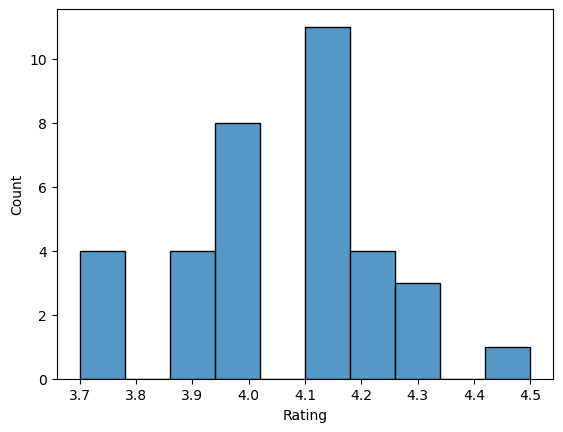

In [26]:
sns.histplot(swiggy_BTM['Rating'],bins=10)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

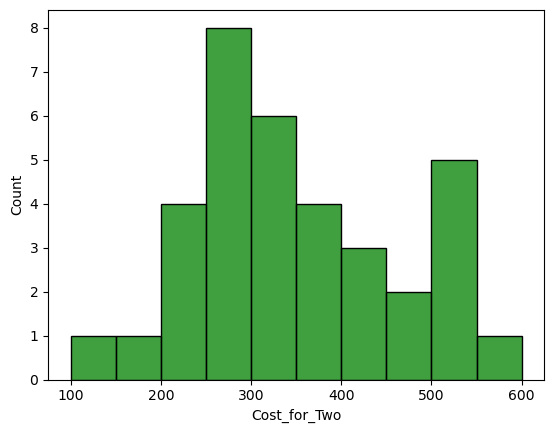

In [27]:
sns.histplot(swiggy_BTM['Cost_for_Two'],bins=10,color='Green')

Conclusion
 BTM: Most has 4.0 to 4.2 Rating and Approx cost for two people lies between 200 to 350(max cost goes upto 600)

HSR Area


<Axes: xlabel='Rating', ylabel='Count'>

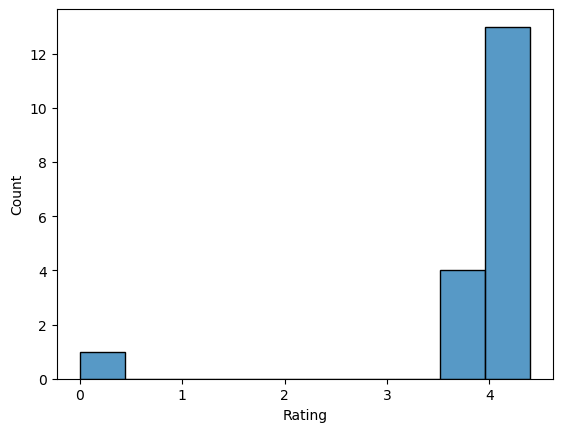

In [28]:
sns.histplot(swiggy_HSR['Rating'],bins=10)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

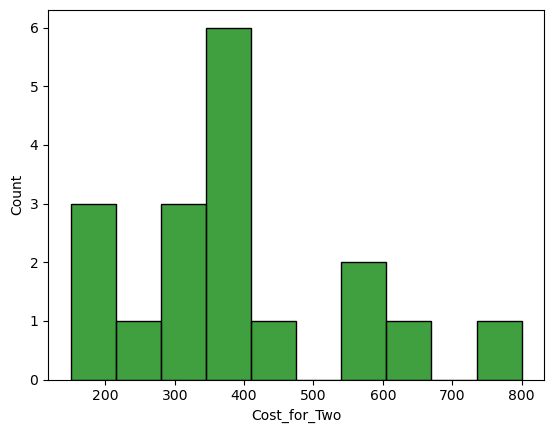

In [29]:
sns.histplot(swiggy_HSR['Cost_for_Two'],bins=10,color='Green')

Conclusion
HSR: Most has 4 or above rating and approx cost for two people lies between 300 to 400(Max. goes upto 800)

Koramangala Area


<Axes: xlabel='Rating', ylabel='Count'>

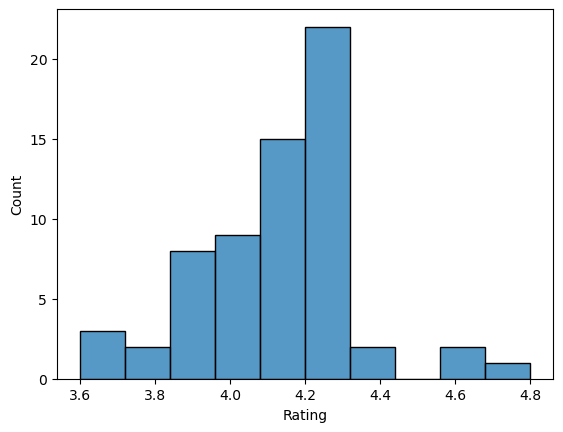

In [30]:
sns.histplot(swiggy_koramangala['Rating'],bins=10)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

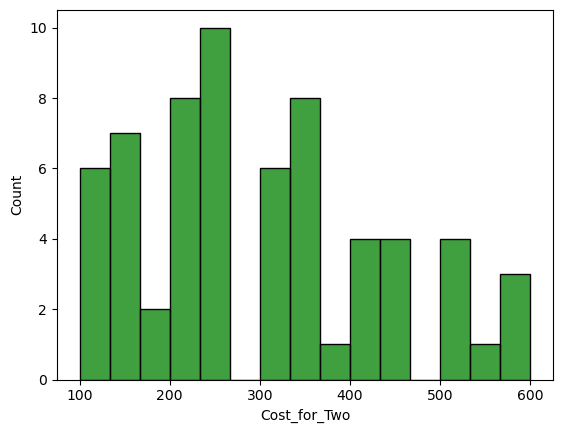

In [31]:
sns.histplot(swiggy_koramangala['Cost_for_Two'],bins=15,color='Green')

conclusion:
koramangala: Most has 4.0 to 4.3 Rating and approx cost for two people lies between 200 to 350(max goes upto 600)

In [32]:
df_Highest_Rated_Restaurants=df_swiggy[df_swiggy['Rating']>4.0]
df_Highest_Rated_Restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
114,Savoury Restaurant,"Arabian, Middle Eastern, North Indian, Grill, ...","Madiwala, BTM",4.1,600
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [33]:
df_Highest_Rated_Restaurants=df_Highest_Rated_Restaurants.loc[:,["Shop_Name","Rating","Cost_for_Two"]]
df_Highest_Rated_Restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
111,Bowl 99,4.4,200
114,Savoury Restaurant,4.1,600
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


In [34]:
fig = px.scatter(
    df_Highest_Rated_Restaurants,
    x=df_Highest_Rated_Restaurants["Cost_for_Two"],
    y=df_Highest_Rated_Restaurants["Rating"],
    color=df_Highest_Rated_Restaurants["Rating"],
    size=df_Highest_Rated_Restaurants["Cost_for_Two"],
    labels={
        "x": "Approx. Cost_for_Two",
        "y": "Rating",
        "color": "Rating_Indicator"
    }
)

fig.update_layout(
    template="plotly_dark",
    title="Analyse 'Approx Cost of 2 People vs Rating'"
)

fig.show()

In [35]:
#  Analyse affordable/Budgeted and highest rated restaurants of Banglore:
df_Affordable_Restaurants=df_swiggy[(df_swiggy["Cost_for_Two"]<=500)&(df_swiggy["Rating"]>=4.0)]
df_Affordable_Restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
110,Biryani Pot,"North Indian, Biryani","Madiwala Junction, BTM",4.0,500
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [36]:
df_Affordable_Restaurants=df_Affordable_Restaurants.loc[:,["Shop_Name","Rating","Cost_for_Two"]]
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
110,Biryani Pot,4.0,500
111,Bowl 99,4.4,200
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


In [37]:
df_Affordable_Restaurants.sort_values(by="Rating",ascending=False,inplace=True)
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
78,Khichdi Experiment,4.8,200
82,Natural Ice Cream,4.6,150
94,Corner House Ice Cream,4.6,250
80,Chinese Bae,4.5,450
3,Al Daaz,4.4,400
...,...,...,...
21,Maa Di Hatti,4.0,129
58,Nanda's,4.0,400
57,Donne Biriyani House,4.0,300
22,Hotel Godavari,4.0,400


C:\Users\DELL\AppData\Local\Temp\ipykernel_10124\4102353605.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




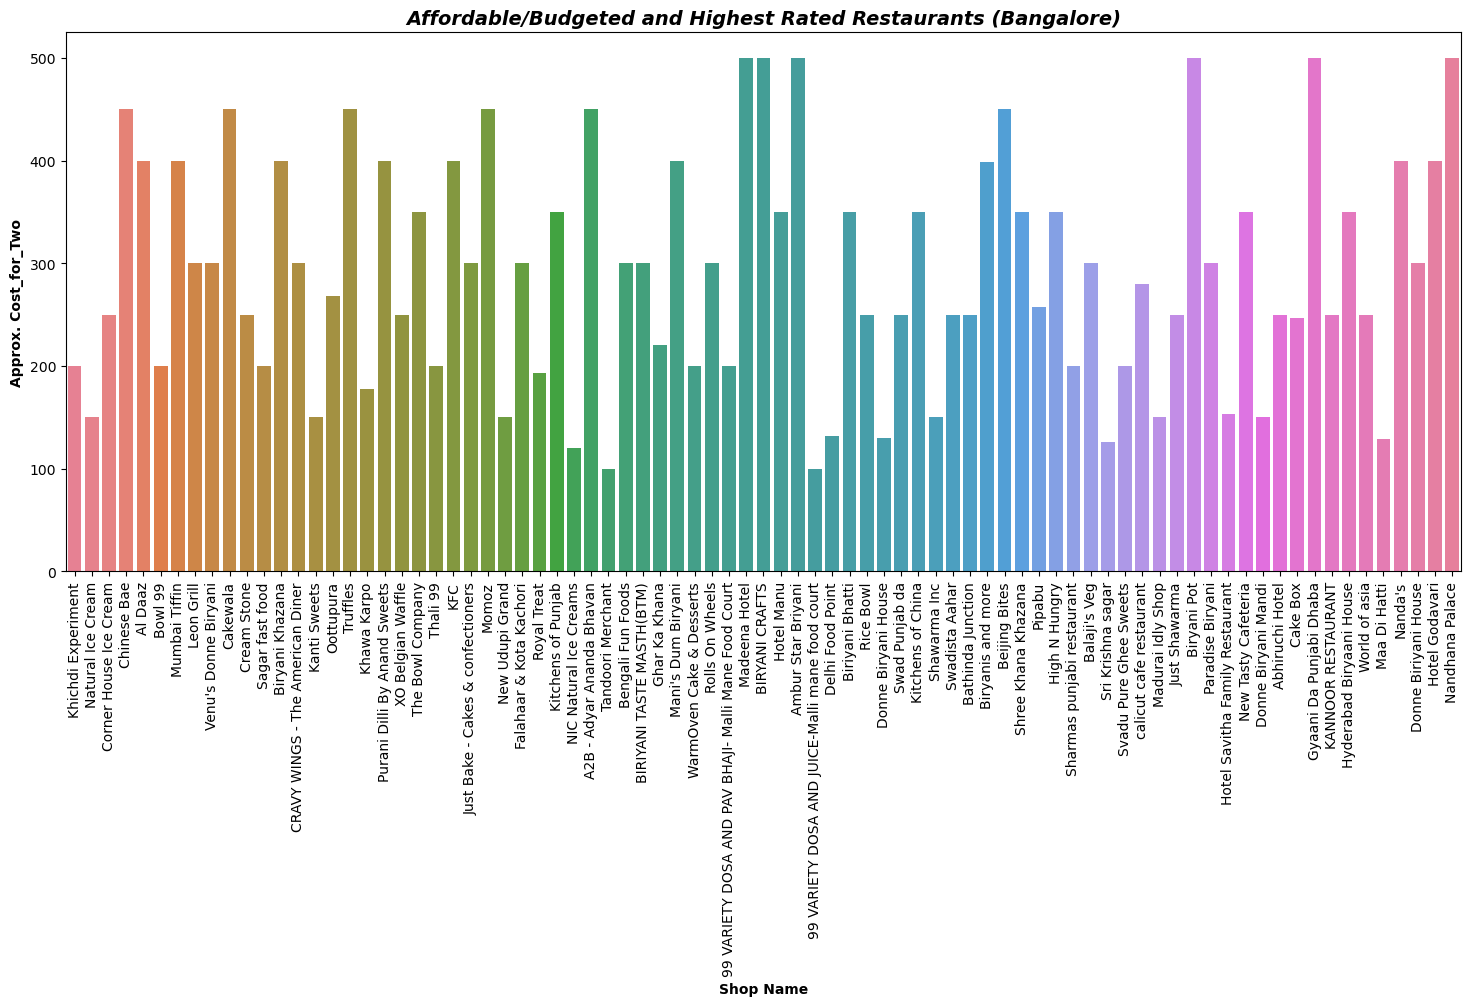

In [38]:
plt.figure(figsize=(18, 7))

sns.barplot(x="Shop_Name",y="Cost_for_Two",data=df_Affordable_Restaurants,palette="husl")

plt.title(
    "Affordable/Budgeted and Highest Rated Restaurants (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic"
)

plt.xlabel("Shop Name", fontsize=10, fontweight="bold")
plt.ylabel("Approx. Cost_for_Two", fontsize=10, fontweight="bold")

plt.xticks(rotation=90)

plt.show()